In [1]:
from gpt import GPT_124
import torch 
import torch.nn as nn
import tiktoken
from torch.utils.data import Dataset,DataLoader

In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50257, 
    "context_length": 256, 
    "emb_dim": 768,       
    "n_heads": 12,        
    "n_layers": 12,       
    "drop_rate": 0.1,     
    "qkv_bias": False      
}

In [3]:
def calc_loss(logits,target):
    """ 
    logits are direct output from gpt -> (batch,n_tokens,n_vocab_size) 
    targets are the target excpected output -> (batch,n_tokens)
    """
    logits_flat = logits.flatten(0, 1)
    target_flat=target.flatten()
    loss=nn.functional.cross_entropy(logits_flat,target_flat)
    return loss

In [4]:
tokenizer=tiktoken.get_encoding("gpt2")
with open("the-verdict.txt","r",encoding="utf-8") as file:
    text=file.read()

total_characters = len(text)
total_tokens = len(tokenizer.encode(text))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20481
Tokens: 5149


#### Dataset class

In [5]:
class GPT_dataset(Dataset):
    def __init__(self,text,tokenizer,context_size,strides):
        self.input_ids=[]
        self.target_ids=[]
        tokens=tokenizer.encode(text,allowed_special={"<|endoftext|>"})
        for i in range(0,len(tokens)-context_size,strides):
            in_tokens=tokens[i:i+context_size] ## input token chunck
            target_tokens=tokens[i+1:i+context_size+1] ## target token chunk
            self.input_ids.append(torch.tensor(in_tokens))
            self.target_ids.append(torch.tensor(target_tokens))
    def __len__(self):
        return len(self.input_ids)  
    def __getitem__(self, index):
        return self.input_ids[index],self.target_ids[index] 


def create_dataloader(txt, batch_size=4, max_length=256, 
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):

    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPT_dataset(txt, tokenizer, max_length, stride)
    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers)

    return dataloader
             

#### DataSplit

In [6]:
## train and validation split
train_ratio = 0.90
split_idx = int(train_ratio * len(text))
train_data = text[:split_idx]
val_data = text[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [7]:
model=GPT_124(GPT_CONFIG_124M)
model.eval() ### No remove dropout for training

GPT_124(
  (token_emd): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_out): Dropout(p=0.1, inplace=False)
  (trf): Sequential(
    (0): Transformer(
      (attn): MultiHeadAttention(
        (W_q): Linear(in_features=768, out_features=768, bias=False)
        (W_k): Linear(in_features=768, out_features=768, bias=False)
        (W_v): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (ff): FeedForward(
        (layer): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNormalization()
      (norm2): LayerNormalization()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): Transformer(
      (attn): MultiHeadAttention(
        (W_q): Linear(in_features=768, out_f

#### Defining loss

In [8]:
def calc_batch_loss(input_batch, target_batch, model, device):
    input_batch,target_batch=input_batch.to(device),target_batch.to(device)
    logits = model(input_batch)
    logits_flat = logits.flatten(0, 1)
    target_flat=target_batch.flatten()
    loss=nn.functional.cross_entropy(logits_flat,target_flat)
    return loss


def get_loader_loss(data_loader, model, device, num_batches=None):
    model.eval()

    total_loss = 0.0
    total_batches = len(data_loader) if num_batches is None else num_batches

    if total_batches == 0:
        return 0.0

    with torch.no_grad():
        for i, (input_batch, target_batch) in enumerate(data_loader):
            if i >= total_batches:
                break

            loss = calc_batch_loss(input_batch, target_batch, model, device)
            total_loss += loss.item()

    return total_loss / total_batches



In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### Some optional function for better clarity

In [10]:
def text_to_token_ids(text, tokenizer): 
    """ Takes input text converts to tokens and make em ready to pass to gpt"""
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())


In [11]:
def text_gen(model,ids,max_token,context_size): ## Needed for inference
    """ 
    ids is input tokens (batch,n_tokens)
    
    """
    for i in range(max_token):
        ids_cl=ids[:,-context_size:] 
        with torch.no_grad():
            out=model(ids_cl)
        last_embd=out[:,-1,:]   
        probs=torch.softmax(last_embd,dim=-1) 
        token=torch.argmax(probs,keepdim=True,dim=-1)
        ids=torch.cat((ids,token),dim=1) 
    return ids    

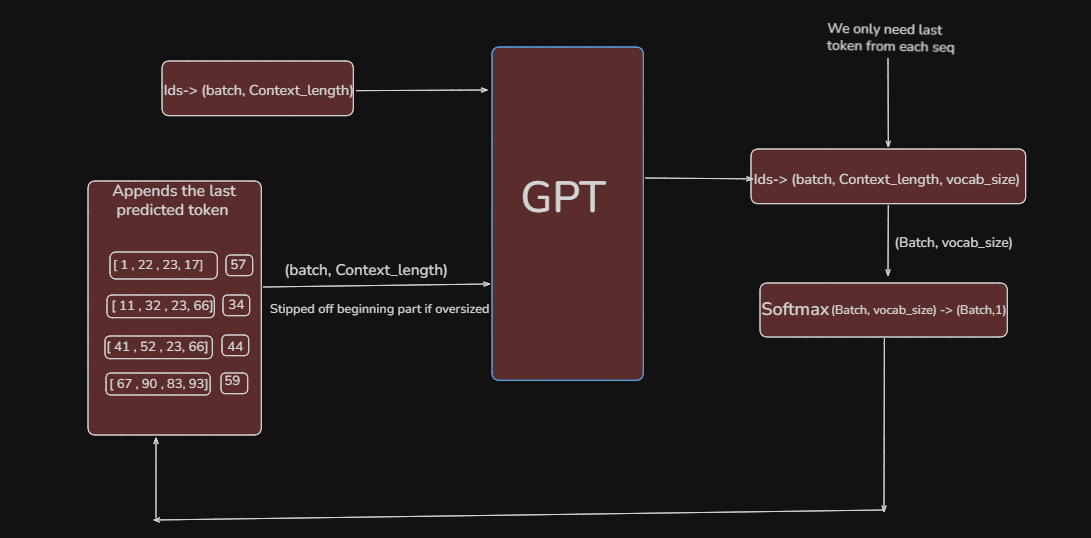

In [16]:
def generate_sample(model, tokenizer, device, start_context,max_token):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device) ## encode a starting sample

    with torch.no_grad():
        token_ids = text_gen(
            model=model, ids=encoded,
            max_token=max_token, context_size=context_size 
        ) ## get token id of generated text upto max

    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

In [13]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = get_loader_loss(train_loader, model, device, num_batches=eval_iter)
        val_loss = get_loader_loss(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [ ]:
def model_train(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], [] ## track loss
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()  
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() ## reset grads 

            loss = calc_batch_loss(input_batch, target_batch, model, device)
            loss.backward() #
            optimizer.step() 
            tokens_seen += input_batch.numel() ## counts no of tokens in input batch
            global_step += 1

            if global_step % eval_freq==0: ## print details on eval freqw
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")
                
                
        generate_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen        

In [15]:

import time
start_time = time.time()

model = GPT_124(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = model_train(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5, ## eval_iter to cover no of batches in validation
    start_context="Every effort moves you", tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.959, Val loss 2.030
Ep 1 (Step 000005): Train loss 8.146, Val loss 1.667
Every effort moves you.                                                 
Ep 2 (Step 000010): Train loss 6.728, Val loss 1.411
Ep 2 (Step 000015): Train loss 6.113, Val loss 1.327
Every effort moves you.                                                 
Ep 3 (Step 000020): Train loss 5.580, Val loss 1.332
Ep 3 (Step 000025): Train loss 5.530, Val loss 1.282
Every effort moves you                                                  
Ep 4 (Step 000030): Train loss 5.077, Val loss 1.292
Ep 4 (Step 000035): Train loss 4.634, Val loss 1.272
Every effort moves you. Gisburn, and, and in the picture. Gisburn. Gisburn, and, and, and had been, and, and had been his wife, and had been his own was his own was the, and in the
Ep 5 (Step 000040): Train loss 4.509, Val loss 1.253
Every effort moves you of the fact's that I felt, and he had been the of the I had been, I had been the fullest.           

In [23]:
start="How are you"
generate_sample(model,tokenizer,device,start,12)

How are you--any more than if I'd never touched a little wild


In [18]:
torch.save({
    "model_state_dict": model.state_dict(),
    "cfg": GPT_CONFIG_124M,
}, "gpt124m.pt")

#### Total number of parameters are 162M

In [19]:
total_params = sum(p.numel() for p in model.parameters())
print(total_params)

162419712
